In [13]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
from notebooks.imports import *

import scipy.io as sio
import h5py

import hdf5storage

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Configs

In [14]:
from config import dir_config, main_config

raw_dir = Path(dir_config.data.raw)
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

SUBJECT_TYPE = "perugini_hc" # hc or pd


### Utils functions

In [15]:
def determine_choice(row):
    if row['is_valid']:
        if row['outcome']:
            return row['target']
        else:
            return 'left' if row['target'] == 'right' else 'right'
    else:
        return np.nan

def get_prior_condition(df):
    valid_df = df[df['is_valid']].copy()  # Ensure valid_df is a copy to avoid SettingWithCopyWarning

    # Calculate trial counts and percentages for each condition within valid trials
    condition_counts = valid_df.groupby(['target', 'color']).size().reset_index(name='counts')
    total_counts = condition_counts.groupby('color')['counts'].transform('sum')
    condition_counts['percentage'] = (condition_counts['counts'] / total_counts) * 100

    # Filter conditions meeting the 60% criterion
    conditions_met = condition_counts[(condition_counts['percentage'] > 60)].copy()  # Make a copy to safely modify

    # Prepare the output based on conditions met
    if not conditions_met.empty:
        # Use .loc to modify 'condition' column safely
        conditions_met.loc[:, 'condition'] = conditions_met.apply(lambda x: 'gr' if x['target'] == "right" and x['color'] == "green"
                                                                else ('gl' if x['target'] == "left" and x['color'] == "green"
                                                                        else ('rr' if x['target'] == "right" and x['color'] == "red"
                                                                            else 'rl')), axis=1)
        return conditions_met[['condition', 'target', 'color']].values.tolist()[0]
    else:
        return ['eq', -1, -1]

### Raw Data Column Description
#### Codes
    - 1001              Start trial
    - 2500              Fixation point ON
    - 2000              Targets appears (white choice cue for correct)
    - 2009              Distractor appears (white choice cue for wrong)
    - 4000:4001     Target (correct choice) is left (4000) or right (4001)
    - 4100:4199     Difficulty levels or coherence levels (4100= easiest)
    - 5000              Glass pattern appears
    - 5500              Glass pattern disappears
    - 5001              (invalid trial)	Failed to hold fixation
    - 5004              (invalid trial)	Failed to hold target
    - 5005              (invalid trial)	Anticipatory saccade
    - 5006              Chose distractor (wrong choice)
    - 5007              Failed to respond on time
    - 5510              Correct choice
    - 1503              The actual key press
    - 6101:6102     Glass pattern color (6101: green)
##### Events (starting with one)
    - 3rd column: GP orientation 
    - 4th column: % coherence {4100:100; 4101:35; 4102:13; 4103:0}
    - 5th column: GP color
    - 9th column: correct? 
##### Time (starting with one)
    - Reaction Time: 8th column - 7th column

## Compiling data from all subjects

In [16]:
KP_data_path = raw_dir / "Perugini_2016" / "Reports_HC_Exp2_KeyPress"
assert KP_data_path.exists(), f"Fragment data path {KP_data_path} does not exist."
EM_data_path = raw_dir / "Perugini_2016" / "Reports_HC_Exp2"
assert EM_data_path.exists(), f"Fragment data path {EM_data_path} does not exist."

# Get folder names
asmHC_KP_folders = [f for f in KP_data_path.iterdir() if f.name.lower().split("_")[1] == "trialbytrial" and f.is_file()]
asmHC_EM_folders = [f for f in EM_data_path.glob("*.xlsx") if f.is_file()]
# folders2 = [f for f in KP_data_path.iterdir() if f.is_file()]
len(asmHC_KP_folders), len(asmHC_EM_folders)

(10, 4)

In [17]:
def process_kp_data(asmHC_KP_folders, save_file=False):
    agg_df = pd.DataFrame()

    for idx, folder in enumerate(asmHC_KP_folders):
        content = hdf5storage.loadmat(folder.as_posix())
        data = content['xyz'].astype(int)
        df = pd.DataFrame(
            {
                "color": np.select([data[:, 3] == 6101, data[:, 3] == 6102], ["green", "red"], default=None),
                "coherence": np.select([data[:, 1] == 4100, data[:, 1] == 4101, data[:, 1] == 4102, data[:, 1] == 4103], [100, 35, 13, 0], default=np.nan),
                "target": np.select([data[:, 2] == 4000, data[:, 2] == 4001], ["left", "right"], default=None),
            }
        )

        invalid_trials = np.where((data[:, 0] == 5007) | (data[:, 4] == 0) | (data[:, 4] == 5005) | (data[:, 4] == 5008))[0]

        df['is_valid'] = ~df.index.isin(invalid_trials)
        df["outcome"] = np.nan
        df.loc[np.where(data[:, 0] == 5510)[0], "outcome"] = 1
        df.loc[np.where(data[:, 4] == 5006)[0], "outcome"] = 0

        df['choice'] = df.apply(determine_choice, axis=1)
        df['reaction_time'] = data[:, 5]


        df["prior"], df["prior_direction"], df["prior_color"] = get_prior_condition(df)

        if save_file:
            subject_id = folder.name.split("_")[0]
            savename = f"{subject_id}_asmHC_KP_{df['prior'].iloc[0]}.mat"
            savepath = compiled_dir / savename
            hdf5storage.savemat(savepath.as_posix(), {"data": df.to_dict('records')})

        df['subject_id'] = folder.name.split("_")[0]
        agg_df = pd.concat([agg_df, df], ignore_index=True)

    return agg_df

In [18]:
def process_em_data(asmHC_EM_folders, save_file=False):

    agg_df = pd.DataFrame()

    for idx, folder in enumerate(asmHC_EM_folders):
        # load the Excel file
        data = pd.read_excel(folder.as_posix())
        data.columns = range(data.shape[1])
        df = pd.DataFrame(
            {
                "color": np.select([data[9] == 6101, data[10] == 6102], ["green", "red"], default=None),
                "coherence": np.select([data[3] == "1:4100", data[4] == 4101, data[5] == 4102, data[6] == 4103], [100, 35, 13, 0], default=np.nan),
                "target": np.select([data[1] == 4000, data[2] == 4001], ["left", "right"], default=None),
            }
        )

        df["outcome"] = np.nan
        df.loc[np.where(data[7] == 5006)[0], "outcome"] = 0
        df.loc[np.where(data[8] == 5510)[0], "outcome"] = 1
        df['is_valid'] = ~df['outcome'].isna()

        df['choice'] = df.apply(determine_choice, axis=1)
        df['reaction_time'] = data[11]

        df["prior"], df["prior_direction"], df["prior_color"] = get_prior_condition(df)

        if save_file:
            subject_id = folder.name.split("_")[0]
            savename = f"{subject_id}_asmHC_EM_{df['prior'].iloc[0]}.mat"
            savepath = compiled_dir / savename
            hdf5storage.savemat(savepath.as_posix(), {"data": df.to_dict('records')})

        df['subject_id'] = folder.name.split("_")[1]

        agg_df = pd.concat([agg_df, df], ignore_index=True)

        return agg_df

In [ ]:
kp_data = process_kp_data(asmHC_KP_folders, save_file=True)
em_data = process_em_data(asmHC_EM_folders, save_file=True)

df = pd.concat([kp_data, em_data], ignore_index=True)

## Recreate Perugini et al 2016 asmHC n=12 control data plot

In [20]:
# remove invalid trials
print(f"Original dataframe shape: {df.shape}")
df = df[df['is_valid']]
print(f"Dataframe shape after removing invalid trials: {df.shape}")

Original dataframe shape: (8375, 11)
Dataframe shape after removing invalid trials: (6948, 11)


In [ ]:
from scipy import stats
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src') if 'notebooks' in os.getcwd() else 'src')
from src.utils import pmf_utils

# --- Prepare data -------------------------------------------------------
# Encode target/choice as numeric (right=1, left=0); signed_coherence = rightward-positive
plot_df = df.copy()
plot_df["target"] = plot_df["target"].map({"right": 0, "left": 1})
plot_df["choice"] = plot_df["choice"].map({"right": 0, "left": 1})
plot_df["signed_coherence"] = plot_df["coherence"] * (2 * plot_df["target"] - 1)
plot_df = plot_df.dropna(subset=["choice", "signed_coherence"])


In [23]:
p_psych, n_psych, e_psych = [], [], []
p_data, n_data, e_data = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()


for subject in plot_df["subject_id"].unique():
    sdata = plot_df[plot_df["subject_id"] == subject]
    coh, psych = pmf_utils.get_psychometric_data(sdata, fit=False)
    # plt.plot(coh, psych, marker="o", label=subject)
    if psych[0] > 0.1 or psych[-1] < 0.9:
        print(f"Subject {subject} has poor performance at extreme coherences: {psych[0]:.2f} (0% coh), {psych[-1]:.2f} (100% coh)")

    if sdata["prior"].iloc[0] == "rr":
        eq_sdata = sdata[sdata["color"] == "green"]
        r_sdata = sdata[sdata["color"] == "red"]
        eq_coh, eq_psych = pmf_utils.get_psychometric_data(eq_sdata, fit=False)
        r_coh, r_psych = pmf_utils.get_psychometric_data(r_sdata, fit=False)
        e_psych.append(eq_psych)
        n_psych.append(r_psych)
        # concatenate data for group-level analysis
        n_data = pd.concat([n_data, r_sdata], ignore_index=True)
        e_data = pd.concat([e_data, eq_sdata], ignore_index=True)

    elif sdata["prior"].iloc[0] == "gr":
        eq_sdata = sdata[sdata["color"] == "red"]
        g_sdata = sdata[sdata["color"] == "green"]
        eq_coh, eq_psych = pmf_utils.get_psychometric_data(eq_sdata, fit=False)
        g_coh, g_psych = pmf_utils.get_psychometric_data(g_sdata, fit=False)
        e_psych.append(eq_psych)
        n_psych.append(g_psych)
        # concatenate data for group-level analysis
        n_data = pd.concat([n_data, g_sdata], ignore_index=True)
        e_data = pd.concat([e_data, eq_sdata], ignore_index=True)

    elif sdata["prior"].iloc[0] == "gl":
        eq_sdata = sdata[sdata["color"] == "red"]
        g_sdata = sdata[sdata["color"] == "green"]
        eq_coh, eq_psych = pmf_utils.get_psychometric_data(eq_sdata, fit=False)
        g_coh, g_psych = pmf_utils.get_psychometric_data(g_sdata, fit=False)
        e_psych.append(eq_psych)
        p_psych.append(g_psych)
        # concatenate data for group-level analysis
        p_data = pd.concat([p_data, g_sdata], ignore_index=True)
        e_data = pd.concat([e_data, eq_sdata], ignore_index=True)

    elif sdata["prior"].iloc[0] == "rl":
        eq_sdata = sdata[sdata["color"] == "green"]
        r_sdata = sdata[sdata["color"] == "red"]
        eq_coh, eq_psych = pmf_utils.get_psychometric_data(eq_sdata, fit=False)
        r_coh, r_psych = pmf_utils.get_psychometric_data(r_sdata, fit=False)
        e_psych.append(eq_psych)
        p_psych.append(r_psych)
        # concatenate data for group-level analysis
        p_data = pd.concat([p_data, r_sdata], ignore_index=True)
        e_data = pd.concat([e_data, eq_sdata], ignore_index=True)


Subject BC has poor performance at extreme coherences: 0.10 (0% coh), 0.87 (100% coh)
Subject BF has poor performance at extreme coherences: 0.06 (0% coh), 0.82 (100% coh)


Text(0.5, 1.0, 'Healthy Controls — Psychometric Functions')

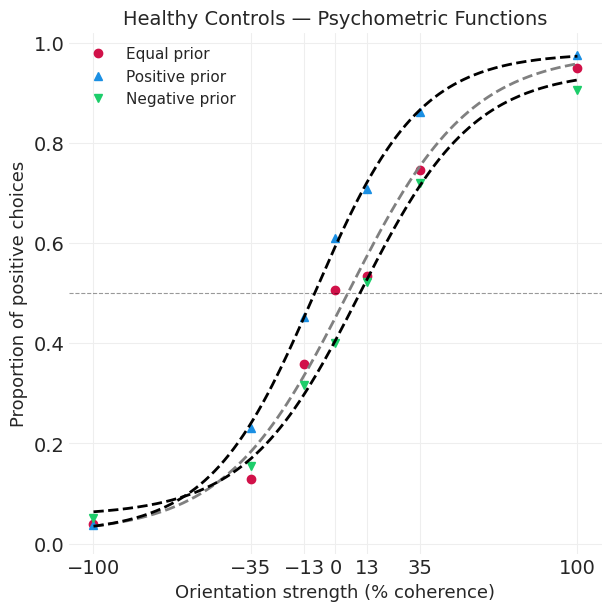

In [24]:
plt.figure(figsize=(6, 6))
plt.plot(eq_coh, np.mean(e_psych, axis=0), marker="o", ls="", label="Equal prior")
y_model = pmf_utils.fit_psychometric_function(eq_coh, np.mean(e_psych, axis=0), trial_counts=None, model_type="logit_3").predict(np.arange(-100, 101, 1))
plt.plot(np.arange(-100, 101, 1), y_model, color="gray", lw=2, ls="--")

plt.plot(r_coh, np.mean(p_psych, axis=0), marker="^", ls="", label="Positive prior")
y_model = pmf_utils.fit_psychometric_function(r_coh, np.mean(p_psych, axis=0), trial_counts=None, model_type="logit_3").predict(np.arange(-100, 101, 1))
plt.plot(np.arange(-100, 101, 1), y_model, color="black", lw=2, ls="--")


plt.plot(g_coh, np.mean(n_psych, axis=0), marker="v", ls="", label="Negative prior")
y_model = pmf_utils.fit_psychometric_function(g_coh, np.mean(n_psych, axis=0), trial_counts=None, model_type="logit_3").predict(np.arange(-100, 101, 1))
plt.plot(np.arange(-100, 101, 1), y_model, color="black", lw=2, ls="--")

plt.xlabel("Orientation strength (% coherence)", fontsize=13)
plt.ylabel("Proportion of positive choices", fontsize=13)
plt.xlim(-110, 110)
plt.ylim(-0.02, 1.02)
plt.xticks([-100, -35, -13, 0, 13, 35, 100])
plt.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.4)
plt.legend(fontsize=11, frameon=False)
plt.title("Healthy Controls — Psychometric Functions", fontsize=14)